The scope of this notebook is to evaluate the properties of the local copy of the arasaac dataset and the dataset used to generate the evaluation dataset. In order to understand how tp treat them in order to allow the agent to correctly work on the evaluation dataset.

In [1]:
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from datasets import load_dataset
from IPython.display import display, HTML

PROJECT_ROOT  = Path("..").resolve()
PICTOGRAMS_EN = PROJECT_ROOT / "app" / "datasets" / "en" / "pictograms.json"
EVAL_PARQUET  = PROJECT_ROOT / "hf_dataset_annotation" / "eval_raw.parquet"
import os
from dotenv import load_dotenv

# Load .env for local development (no-op on cluster where HF_TOKEN is set via env)
load_dotenv(Path('../app/.env'))
HF_TOKEN      = os.environ.get("HF_TOKEN", "")
HF_REPO_SRC   = "disi-unibo-nlp-students/ARASAAC-Pictograms"

/Users/pelle/python_venvs/BDATM/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load datasets

In [2]:
# SRC_LOCAL
with open(PICTOGRAMS_EN, encoding="utf-8") as f:
    local_pics = json.load(f)
df_local = pd.DataFrame.from_dict(local_pics, orient="index")
df_local.drop(["id"], axis=1, inplace=True)
df_local.index = df_local.index.astype(int)
df_local = df_local.reset_index().rename(columns={"index": "pictogram_id"})

# SRC_HF
df_hf = load_dataset(HF_REPO_SRC, split="train", token=HF_TOKEN)              
df_hf = df_hf.to_pandas()     

# Align the 2 datasets
df_local = df_local.sort_values("pictogram_id").reset_index(drop=True)
df_hf = df_hf.sort_values("pictogram_id").reset_index(drop=True)

# EVAL
df_eval = pd.read_parquet(EVAL_PARQUET)

# Show 
display(df_local)
display(df_hf)
display(df_eval)

Using the latest cached version of the dataset since disi-unibo-nlp-students/ARASAAC-Pictograms couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at /Users/pelle/.cache/huggingface/datasets/disi-unibo-nlp-students___arasaac-pictograms/default/0.0.0/34df552d9b3394a803d037894628a66a13d49be6 (last modified on Mon Apr 20 14:50:05 2026).


,pictogram_id,keywords,categories,synsets,tags,sex,violence,schematic,aac,aac_color,skin,hair,created,last_updated
0,2239,"[{'type': 2, 'keyword': 'bee', 'plural': 'bees...","[herbivorous, insect, oviparous, flying animal...",[02209508-n],"[animal, herbivorous, invertebrate, arthropod,...",False,False,False,False,False,False,False,2007-12-11T21:59:56.000Z,2020-12-27T11:59:40.369Z
1,2242,"[{'type': 2, 'keyword': 'coat', 'plural': 'coa...","[clothes, core vocabulary-object, fashion]","[03061006-n, 03461607-n, 04195013-n]","[object, fashion, clothes, core vocabulary]",False,False,False,True,True,False,False,2007-12-12T09:33:40.000Z,2024-12-09T06:11:43.097Z
2,2243,"[{'type': 2, 'keyword': 'grandmother', 'plural...","[elderly, family]",[10162267-n],"[person, elderly, family]",False,False,False,False,False,True,True,2007-12-12T09:56:39.000Z,2022-06-14T17:58:08.293Z
3,2244,"[{'type': 2, 'keyword': 'grandfather', 'plural...","[elderly, family]",[10161911-n],"[person, elderly, family]",False,False,False,False,False,True,True,2007-12-12T09:57:36.000Z,2020-11-26T10:23:32.187Z
4,2245,"[{'type': 4, 'keyword': 'boring', 'plural': No...","[qualifying adjective, feeling]",[01348155-s],"[communication, language, adjective, qualifyin...",False,False,False,False,False,True,False,2007-12-12T09:58:31.000Z,2020-11-22T15:44:11.932Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13775,39853,"[{'type': 3, 'keyword': 'put nursery robe on',...","[verb, clothes, students]",[00050369-v],"[communication, language, verb, object, fashio...",False,False,False,False,False,True,True,2026-04-12T10:21:07.958Z,2026-04-13T08:58:06.530Z
13776,39854,"[{'type': 2, 'keyword': 'amphitheater', 'plura...","[cultural building, monument]",[],"[place, building, culture, monument]",False,False,False,False,False,False,True,2026-04-12T10:21:07.958Z,2026-04-13T08:54:07.390Z
13777,39855,"[{'type': 4, 'keyword': 'many months ago', 'pl...",[adverb of time],[],"[communication, language, adverb, adverb of time]",False,False,False,False,False,False,False,2026-04-13T10:31:28.953Z,2026-04-13T11:33:37.188Z
13778,39856,"[{'type': 4, 'keyword': 'relieved', 'plural': ...","[verb, human response]",[],"[communication, language, verb, psychology, hu...",False,False,True,False,False,True,False,2026-04-13T10:31:28.953Z,2026-04-13T11:45:28.104Z


,image,pictogram_id,tags,categories,keywords
0,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,2239,"[animal, herbivorous, invertebrate, arthropod,...","[herbivorous, insect, oviparous, flying animal...","[{'hasLocution': True, 'keyword': 'bee', 'mean..."
1,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,2242,"[object, fashion, clothes, core vocabulary]","[clothes, core vocabulary-object]","[{'hasLocution': True, 'keyword': 'coat', 'mea..."
2,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,2243,"[person, elderly, family]","[elderly, family]","[{'hasLocution': True, 'keyword': 'grandmother..."
3,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,2244,"[person, elderly, family]","[elderly, family]","[{'hasLocution': True, 'keyword': 'grandfather..."
4,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,2245,"[communication, language, adjective, qualifyin...","[qualifying adjective, feeling]","[{'hasLocution': True, 'keyword': 'boring', 'm..."
...,...,...,...,...,...
12469,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,38548,"[communication, language, verb, leisure, sport...","[verb, sport modality]","[{'hasLocution': False, 'keyword': 'golf', 'me..."
12470,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,38549,"[communication, language, verb, leisure, sport...","[verb, traditional game]","[{'hasLocution': False, 'keyword': 'play petan..."
12471,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,38550,"[communication, language, verb, usual verbs, p...","[usual verbs, basic needs, routine]","[{'hasLocution': False, 'keyword': 'sleep in t..."
12472,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,38552,"[health, medicine, medical equipment, nursing ...","[nursing equipment, orthopedic product]","[{'hasLocution': False, 'keyword': 'anti-bedso..."


,sentence,concept,best_id
0,skier ski down the mountain,"[skier, ski, the mountain]","[35959, 3097, 23977]"
1,a skier be ski down a mountain .,"[a skier, ski, a mountain]","[3097, 3098, 23977]"
2,three skiers be ski on a snowy mountain .,"[three skiers, ski, a snowy mountain]","[35959, 28815, 38261]"
3,the dog be wag his tail .,"[the dog, wag, his tail]","[7139, 36179, 5967]"
4,a dog wag his tail at the boy .,"[a dog, wag, his tail, the boy]","[11176, 25996, 5967, 36481]"
...,...,...,...
54792,type of place of worship of artwork show a tem...,"[type, place, worship, artwork, a temple, reli...","[11098, 21861, 24189, 21859, 36550, 23833]"
54793,a lot of people be gather in a pier next to a ...,"[a lot, people, gather, a pier, a lake, people...","[36081, 11486, 7116, 37115, 6159, 28031]"
54794,dimensional sculpture in the round mythical be...,"[dimensional sculpture, the round mythical bea...","[21859, 6237, 5472, 21861, 4603, 6573, 7302]"
54795,type of place of worship of artwork feature a ...,"[type, place, worship, artwork feature, a temp...","[7074, 21861, 24189, 38382, 36550, 27060]"


## 2. Dataset quality evaluation and cleaning

In [3]:
def check_dataset_quality(df: pd.DataFrame, keyword_schema: str = "local") -> dict:
    """
    Quality checks on an ARASAAC pictogram dataframe.
    Returns a dict with raw results; prints a summary report.

    keyword_schema: "local" expects list of dicts with {type: int, keyword: str, meaning: str}
                    "hf"    expects array of dicts with {hasLocution: bool, keyword: str, meaning: str}

    Checks:
      1. Unique pictogram_id (no duplicates)
      2. None / NaN in key columns
      3. Empty lists in list-columns (keywords, categories, tags, synsets)
      4. Keywords: malformed entries (missing/wrong-type required fields)
      5. Categories: non-string or empty-string values inside the list
      6. Synsets: format check (expected WordNet offset e.g. "08437235-n")
    """
    KEY_COLS  = ["pictogram_id", "keywords", "categories", "tags"]
    LIST_COLS = ["keywords", "categories", "tags"]
    if "synsets" in df.columns:
        LIST_COLS.append("synsets")

    results = {}
    n = len(df)

    # 1. Duplicate IDs
    dup_mask = df["pictogram_id"].duplicated(keep=False)
    results["duplicate_ids"] = {
        "count": int(dup_mask.sum()),
        "ids":   df.loc[dup_mask, "pictogram_id"].tolist(),
    }

    # 2. None / NaN in key columns
    none_counts = {}
    for col in KEY_COLS:
        if col not in df.columns:
            none_counts[col] = "MISSING"
            continue
        mask = df[col].isna()
        if df[col].dtype == object:
            mask = mask | (df[col].astype(str) == "None")
        none_counts[col] = int(mask.sum())
    results["none_values"] = none_counts

    # 3. Empty lists in list-columns
    empty_list_counts = {}
    for col in LIST_COLS:
        if col not in df.columns:
            empty_list_counts[col] = "MISSING"
            continue
        mask = df[col].apply(lambda x: isinstance(x, list) and len(x) == 0)
        empty_list_counts[col] = int(mask.sum())
    results["empty_lists"] = empty_list_counts

    # 4. Keywords: malformed entries
    def _valid_keyword_entry(k, schema):
        if not isinstance(k, dict):
            return False
        if not (isinstance(k.get("keyword"), str) and k["keyword"].strip()):
            return False
        if not isinstance(k.get("meaning"), str):
            return False
        if schema == "local":
            return isinstance(k.get("type"), int)
        else:  # hf
            return isinstance(k.get("hasLocution"), (bool, np.bool_))

    def _malformed_keywords(kws):
        if not isinstance(kws, (list, np.ndarray)):
            return True
        return any(not _valid_keyword_entry(k, keyword_schema) for k in kws)

    if "keywords" in df.columns:
        malformed_mask = df["keywords"].apply(_malformed_keywords)
        results["keywords_malformed"] = {
            "count": int(malformed_mask.sum()),
            "pct":   round(malformed_mask.mean() * 100, 2),
        }

    # 5. Categories: bad values inside the list
    def _bad_categories(cats):
        if (not isinstance(cats, list)) and (not isinstance(cats, np.ndarray)):
            return True
        return any(not isinstance(c, str) or c.strip() == "" for c in cats)

    if "categories" in df.columns:
        bad_cat_mask = df["categories"].apply(_bad_categories)
        results["categories_bad_values"] = {
            "count": int(bad_cat_mask.sum()),
            "pct":   round(bad_cat_mask.mean() * 100, 2),
        }

    # 6. Synsets: format check
    import re
    _SYNSET_RE = re.compile(r"^\s*\d{1,8}-[nvars]\s*$")

    def _bad_synsets(syns):
        if not isinstance(syns, list):
            return False
        return any(not isinstance(s, str) or not _SYNSET_RE.match(s) for s in syns)
    
    if "synsets" in df.columns:
        bad_syn_mask = df["synsets"].apply(_bad_synsets)
        results["synsets_bad_format"] = {
            "count": int(bad_syn_mask.sum()),
            "pct":   round(bad_syn_mask.mean() * 100, 2),
        }

    # Report
    sep = "-" * 50
    print(sep)
    print(f"Dataset quality report  ({n} rows, schema={keyword_schema})")
    print(sep)

    dup = results["duplicate_ids"]
    print(f"\n[1] Duplicate pictogram_ids: {dup['count']}")
    if dup["count"]:
        preview = dup["ids"][:10]
        print(f"    ids: {preview}{'...' if len(dup['ids']) > 10 else ''}")

    print(f"\n[2] None / NaN in key columns")
    for col, cnt in results["none_values"].items():
        print(f"    {col:20s}: {cnt}")

    print(f"\n[3] Empty lists in list-columns")
    for col, cnt in results["empty_lists"].items():
        print(f"    {col:20s}: {cnt}")

    if "keywords_malformed" in results:
        r = results["keywords_malformed"]
        print(f"\n[4] Malformed keyword entries: {r['count']}  ({r['pct']}%)")

    if "categories_bad_values" in results:
        r = results["categories_bad_values"]
        print(f"\n[5] Bad category values: {r['count']}  ({r['pct']}%)")

    if "synsets_bad_format" in results:
        r = results["synsets_bad_format"]
        print(f"\n[6] Synsets with bad format: {r['count']}  ({r['pct']}%)")

    print(f"\n{sep}\n")
    return results

### 2.1 Local

In [4]:
quality_local = check_dataset_quality(df_local, keyword_schema="local")

--------------------------------------------------
Dataset quality report  (13780 rows, schema=local)
--------------------------------------------------

[1] Duplicate pictogram_ids: 0

[2] None / NaN in key columns
    pictogram_id        : 0
    keywords            : 0
    categories          : 0
    tags                : 0

[3] Empty lists in list-columns
    keywords            : 0
    categories          : 35
    tags                : 100
    synsets             : 1213

[4] Malformed keyword entries: 9827  (71.31%)

[5] Bad category values: 0  (0.0%)

[6] Synsets with bad format: 39  (0.28%)

--------------------------------------------------



In [5]:
############################################################################
########################## Show problematic lines ##########################
############################################################################

import re
VERBOSE = True

##################### [3] Empty lists in list-columns #####################

# a) Filter empty rows
list_cols = ["keywords", "categories", "tags", "synsets"]
empty_masks = {
    col: df_local[col].apply(lambda x: isinstance(x, list) and len(x) == 0)
    for col in list_cols
    if col in df_local.columns
}
if VERBOSE:
    for c in empty_masks:
        print(f"Rows with empty {c}")
        display(df_local[empty_masks[c]])

# b) How many with multiple empty?
multiple_mask = sum(empty_masks.values()) >= 2
if VERBOSE:
    display(df_local[multiple_mask][list(empty_masks.keys())])
print(f"==> There are {multiple_mask.sum()} rows with multiple empty cols")

###################### [4] Malformed keyword entries ######################

def _kw_signature(e):
    return (e.get("type"), e.get("keyword"), e.get("meaning"))

malformations = {}
kw_signatures = {}  # keyword -> set of distinct signatures seen
kw_entries    = {}  # keyword -> dict of signature -> entry (for display)
kw_malformed  = {}  # keyword -> reasons (distinct malformed keywords only)

for i, row in df_local.iterrows():
    reasons = []
    l = row["keywords"]
    if not isinstance(l, list):
        reasons.append(f"Keywords is not a list: {type(l)}")
    else:
        for e in l:
            if not isinstance(e, dict):
                reasons.append(f"Wrong keyword type: {type(e)}")
                continue

            k = e.get("keyword")
            kw_reasons = []

            if not (isinstance(k, str) and k.strip()):
                kw_reasons.append(f"Wrong keyword name: {k!r}")
            m = e.get("meaning")
            if not (isinstance(m, str) and m.strip()):
                kw_reasons.append(f"Wrong meaning: {m!r}")
            t = e.get("type")
            if not isinstance(t, int):
                kw_reasons.append(f"Wrong type field: {t!r}")

            sig = _kw_signature(e)
            if k not in kw_signatures:
                kw_signatures[k] = set()
                kw_entries[k] = {}
            kw_signatures[k].add(sig)
            kw_entries[k][sig] = e

            if k not in kw_malformed and kw_reasons:
                kw_malformed[k] = kw_reasons

            reasons.extend(kw_reasons)

    if reasons:
        malformations[i] = reasons

kw_duplicates = {k: kw_entries[k] for k in kw_signatures if len(kw_signatures[k]) > 1}

print(f"==> {len(malformations)} rows with at least one malformed keyword entry")
print(f"    {len(kw_malformed)}/{len(kw_signatures)} distinct keywords malformed")
print(f"    malformed breakdown by reason:")
reason_counter = Counter(r for reasons in kw_malformed.values() for r in reasons)
for reason, count in reason_counter.most_common():
    print(f"    {count:6d}  {reason}")
print(f"    {len(kw_duplicates)} keywords with inconsistent structure across rows")
if kw_duplicates:
    for k, sig_to_entry in kw_duplicates.items():
        print(f"      {k!r} ({len(sig_to_entry)} distinct structures):")
        for e in sig_to_entry.values():
            print(f"        {e}")

######################### [5] Malformed categories #########################

cat_malformations = {}
cat_reason_counter = Counter()

for i, row in df_local.iterrows():
    reasons = []
    cats = row["categories"]
    if not isinstance(cats, list):
        reasons.append(f"Categories is not a list: {type(cats)}")
    else:
        for c in cats:
            if not isinstance(c, str) or not c.strip():
                reasons.append(f"Bad category value: {c!r}")
    if reasons:
        cat_malformations[i] = reasons
        for r in reasons:
            cat_reason_counter[r] += 1

if VERBOSE:
    for i, reasons in cat_malformations.items():
        print(f"{i})")
        for r in reasons:
            print(f"\t{r}")
print(f"==> {len(cat_malformations)} rows with malformed categories")
if cat_reason_counter:
    print(f"    breakdown by reason:")
    for reason, count in cat_reason_counter.most_common():
        print(f"    {count:6d}  {reason}")

########################## [6] Malformed synsets ###########################

_SYNSET_RE = re.compile(r"^\s*\d{1,8}-[nvars]\s*$")

syn_malformations = {}
syn_reason_counter = Counter()

for i, row in df_local.iterrows():
    reasons = []
    syns = row["synsets"]
    if not isinstance(syns, list):
        reasons.append(f"Synsets is not a list: {type(syns)}")
    else:
        for s in syns:
            if not isinstance(s, str) or not _SYNSET_RE.match(s):
                reasons.append(f"Bad synset value: {s!r}")
    if reasons:
        syn_malformations[i] = reasons
        for r in reasons:
            syn_reason_counter[r] += 1

if VERBOSE:
    for i, reasons in syn_malformations.items():
        print(f"{i})")
        for r in reasons:
            print(f"\t{r}")
print(f"==> {len(syn_malformations)} rows with malformed synsets")
if syn_reason_counter:
    print(f"    breakdown by reason:")
    for reason, count in syn_reason_counter.most_common():
        print(f"    {count:6d}  {reason}")

Rows with empty keywords


,pictogram_id,keywords,categories,synsets,tags,sex,violence,schematic,aac,aac_color,skin,hair,created,last_updated


Rows with empty categories


,pictogram_id,keywords,categories,synsets,tags,sex,violence,schematic,aac,aac_color,skin,hair,created,last_updated
142,2386,"[{'type': 2, 'keyword': 'shelves', 'plural': N...",[],[04197095-n],[],False,False,False,True,True,False,False,2007-12-13T13:09:16.000Z,2021-02-05T09:59:12.185Z
384,2641,"[{'type': 2, 'keyword': 'garlic', 'plural': 'g...",[],"[07834253-n, 12455280-n]",[],False,False,False,False,False,False,False,2007-12-19T10:07:50.000Z,2020-05-30T05:42:21.378Z
655,2946,"[{'type': 2, 'keyword': 'bow', 'plural': 'bows...",[],"[02883550-n, 03632523-n]",[],False,False,False,False,False,False,False,2008-01-15T13:29:56.000Z,2019-12-27T19:27:56.788Z
684,2975,"[{'type': 2, 'keyword': 'hairpin', 'plural': '...",[],[03481436-n],[],False,False,False,False,False,False,False,2008-01-15T14:11:37.000Z,2019-12-27T12:24:19.775Z
2290,6937,"[{'type': 2, 'keyword': 'pocket', 'plural': 'p...",[],[03978882-n],[],False,False,False,True,True,False,False,2009-01-09T13:52:22.000Z,2021-02-06T07:48:29.947Z
3063,8474,"[{'type': 6, 'keyword': 'a', 'plural': None, '...",[],[],"[communication, language, article]",False,False,True,False,False,False,False,2009-04-29T22:21:34.000Z,2024-11-06T16:11:01.941Z
4134,11406,"[{'type': 2, 'keyword': 'ballet shoes', 'plura...",[],"[04248522-n, 00529704-n]",[],False,False,False,False,False,False,False,2009-12-26T19:07:20.000Z,2020-06-01T07:32:14.041Z
4551,15357,"[{'type': 2, 'keyword': 'tape', 'plural': 'tap...",[],[02788021-n],[],False,False,False,False,False,False,False,2010-04-08T22:38:44.000Z,2020-01-22T19:54:42.275Z
4633,15523,"[{'type': 2, 'keyword': 'obligation', 'plural'...",[],[01132241-n],[],False,False,False,False,False,False,False,2010-04-10T17:32:57.000Z,2025-12-24T16:17:46.458Z
4715,16000,"[{'type': 3, 'keyword': 'disagree with', 'plur...",[],"[02759740-v, 00809123-v]",[],False,False,True,False,False,True,False,2010-04-16T11:26:57.000Z,2020-12-16T12:06:25.113Z


Rows with empty tags


,pictogram_id,keywords,categories,synsets,tags,sex,violence,schematic,aac,aac_color,skin,hair,created,last_updated
142,2386,"[{'type': 2, 'keyword': 'shelves', 'plural': N...",[],[04197095-n],[],False,False,False,True,True,False,False,2007-12-13T13:09:16.000Z,2021-02-05T09:59:12.185Z
384,2641,"[{'type': 2, 'keyword': 'garlic', 'plural': 'g...",[],"[07834253-n, 12455280-n]",[],False,False,False,False,False,False,False,2007-12-19T10:07:50.000Z,2020-05-30T05:42:21.378Z
655,2946,"[{'type': 2, 'keyword': 'bow', 'plural': 'bows...",[],"[02883550-n, 03632523-n]",[],False,False,False,False,False,False,False,2008-01-15T13:29:56.000Z,2019-12-27T19:27:56.788Z
684,2975,"[{'type': 2, 'keyword': 'hairpin', 'plural': '...",[],[03481436-n],[],False,False,False,False,False,False,False,2008-01-15T14:11:37.000Z,2019-12-27T12:24:19.775Z
1694,5590,"[{'type': 2, 'keyword': 'dream', 'plural': 'dr...",[miscellaneous],[05776550-n],[],False,False,False,False,False,True,True,2008-09-18T09:51:34.000Z,2020-12-29T06:23:58.757Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11689,37665,"[{'type': 2, 'keyword': 'prosecutor', 'plural'...",[],"[08081578-n, 10504443-n]",[],False,False,True,False,False,True,False,2021-06-25T08:54:31.084Z,2021-06-25T17:58:09.210Z
11722,37699,"[{'type': 3, 'keyword': 'blow up', 'plural': N...",[],[00264920-v],[],False,False,True,False,False,True,False,2021-08-21T10:11:20.376Z,2021-08-21T13:55:00.550Z
12517,38504,"[{'type': 2, 'keyword': 'ham sandwich', 'plura...",[],"[07712370-n, 07711710-n]",[],False,False,False,False,False,False,False,2022-07-14T13:38:30.326Z,2022-07-30T16:58:32.895Z
13125,39147,"[{'type': 2, 'keyword': 'privacy', 'plural': N...",[miscellaneous],[],[],False,False,True,False,False,True,False,2024-03-26T10:44:20.879Z,2024-03-26T12:52:37.626Z


Rows with empty synsets


,pictogram_id,keywords,categories,synsets,tags,sex,violence,schematic,aac,aac_color,skin,hair,created,last_updated
351,2608,"[{'type': 1, 'keyword': 'you', 'plural': None,...","[pronoun, personal pronoun]",[],"[communication, language, pronoun, personal pr...",False,False,False,False,False,True,False,2007-12-18T13:37:55.000Z,2024-10-20T05:28:32.821Z
360,2617,"[{'type': 1, 'keyword': 'I', 'plural': None, '...","[pronoun, personal pronoun]",[],"[communication, language, pronoun, personal pr...",False,False,False,False,False,True,False,2007-12-18T13:48:22.000Z,2024-10-20T05:31:30.873Z
545,2825,"[{'type': 2, 'keyword': 'feather duster', 'plu...",[cleaning product],[],"[object, cleaning product]",False,False,False,False,False,False,False,2008-01-14T17:41:36.000Z,2020-06-03T09:37:31.195Z
883,3177,"[{'type': 6, 'keyword': '@', 'plural': None, '...",[orthographic sign],[],"[communication, language, alphabet, orthograph...",False,False,False,False,False,False,False,2008-01-25T12:35:48.000Z,2020-06-02T11:28:33.705Z
907,3204,"[{'type': 2, 'keyword': 'party blower', 'plura...",[christmas],[],"[event, popular event, christmas]",False,False,False,False,False,False,False,2008-01-25T13:52:14.000Z,2020-12-10T12:45:56.594Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13774,39852,"[{'type': 2, 'keyword': 'rugby player', 'plura...",[athlete],[],"[leisure, sport, person]",False,False,False,False,False,True,True,2026-04-12T10:21:07.958Z,2026-04-13T10:24:16.167Z
13776,39854,"[{'type': 2, 'keyword': 'amphitheater', 'plura...","[cultural building, monument]",[],"[place, building, culture, monument]",False,False,False,False,False,False,True,2026-04-12T10:21:07.958Z,2026-04-13T08:54:07.390Z
13777,39855,"[{'type': 4, 'keyword': 'many months ago', 'pl...",[adverb of time],[],"[communication, language, adverb, adverb of time]",False,False,False,False,False,False,False,2026-04-13T10:31:28.953Z,2026-04-13T11:33:37.188Z
13778,39856,"[{'type': 4, 'keyword': 'relieved', 'plural': ...","[verb, human response]",[],"[communication, language, verb, psychology, hu...",False,False,True,False,False,True,False,2026-04-13T10:31:28.953Z,2026-04-13T11:45:28.104Z


,keywords,categories,tags,synsets
142,"[{'type': 2, 'keyword': 'shelves', 'plural': N...",[],[],[04197095-n]
384,"[{'type': 2, 'keyword': 'garlic', 'plural': 'g...",[],[],"[07834253-n, 12455280-n]"
655,"[{'type': 2, 'keyword': 'bow', 'plural': 'bows...",[],[],"[02883550-n, 03632523-n]"
684,"[{'type': 2, 'keyword': 'hairpin', 'plural': '...",[],[],[03481436-n]
2290,"[{'type': 2, 'keyword': 'pocket', 'plural': 'p...",[],[],[03978882-n]
3063,"[{'type': 6, 'keyword': 'a', 'plural': None, '...",[],"[communication, language, article]",[]
4134,"[{'type': 2, 'keyword': 'ballet shoes', 'plura...",[],[],"[04248522-n, 00529704-n]"
4551,"[{'type': 2, 'keyword': 'tape', 'plural': 'tap...",[],[],[02788021-n]
4633,"[{'type': 2, 'keyword': 'obligation', 'plural'...",[],[],[01132241-n]
4715,"[{'type': 3, 'keyword': 'disagree with', 'plur...",[],[],"[02759740-v, 00809123-v]"


==> There are 38 rows with multiple empty cols
==> 9827 rows with at least one malformed keyword entry
    11665/15757 distinct keywords malformed
    malformed breakdown by reason:
     11665  Wrong meaning: None
    1796 keywords with inconsistent structure across rows
      'coat' (2 distinct structures):
        {'type': 2, 'keyword': 'coat', 'plural': 'coats', 'meaning': 'm. Clothing, long, fitted sleeves, worn over the other and serves to entertain.'}
        {'type': 2, 'keyword': 'coat', 'plural': 'coats', 'meaning': None}
      'boring' (2 distinct structures):
        {'type': 4, 'keyword': 'boring', 'plural': None, 'meaning': 'adj. Guan that the tire.'}
        {'type': 4, 'keyword': 'boring', 'plural': None, 'meaning': None}
      'dull' (2 distinct structures):
        {'type': 4, 'keyword': 'dull', 'plural': None, 'meaning': None}
        {'type': 3, 'keyword': 'dull', 'plural': None, 'meaning': None}
      'oil' (4 distinct structures):
        {'type': 2, 'keyword': 'oi

The local dataset seems healthy:
- The multiple empty cols are not frequent and possible.
- The malformed rows are due to:
    - keywords: they are ok since it only conceerns the meaning. This is not even a problem since they are variations of meaning not exaplained and not really duplicates.
    - synsets: they are not a problems since they are few and oly occur for expansion, while the real source of info is the keyword.

### 2.2 HF pictogram dataset

In [6]:
quality_hf = check_dataset_quality(df_hf, keyword_schema="hf")

--------------------------------------------------
Dataset quality report  (12474 rows, schema=hf)
--------------------------------------------------

[1] Duplicate pictogram_ids: 20
    ids: [38264, 38264, 38265, 38265, 38266, 38266, 38267, 38267, 38268, 38268]...

[2] None / NaN in key columns
    pictogram_id        : 0
    keywords            : 1817
    categories          : 1817
    tags                : 1817

[3] Empty lists in list-columns
    keywords            : 0
    categories          : 0
    tags                : 0

[4] Malformed keyword entries: 8871  (71.12%)

[5] Bad category values: 1817  (14.57%)

--------------------------------------------------



In [7]:
############################################################################
########################## Show problematic lines ##########################
############################################################################

VERBOSE = True

##################### [1] Duplicate pictogram_ids #########################

import json

def _row_to_comparable(row_dict):
    """Serialize a row dict to a JSON string for equality comparison.
    Handles lists, numpy arrays, and numpy scalars."""
    def _convert(v):
        if isinstance(v, np.ndarray):
            return v.tolist()
        if isinstance(v, (np.integer, np.floating, np.bool_)):
            return v.item()
        return v
    return json.dumps({k: _convert(v) for k, v in row_dict.items()}, sort_keys=True, default=str)

dup_ids  = set(quality_hf["duplicate_ids"]["ids"])
dup_mask = df_hf["pictogram_id"].isin(dup_ids)
df_dups  = df_hf[dup_mask].sort_values("pictogram_id").reset_index(drop=True)

identical_ids, divergent_ids = [], []
for pid in sorted(dup_ids):
    copies = df_hf[df_hf["pictogram_id"] == pid]
    rows   = [_row_to_comparable(copies.iloc[i].to_dict()) for i in range(len(copies))]
    if rows[0] == rows[1]:
        identical_ids.append(pid)
    else:
        divergent_ids.append(pid)

print(f"==> {len(dup_ids)} IDs appear more than once  "
      f"({len(identical_ids)} identical copies, {len(divergent_ids)} divergent)")
if divergent_ids:
    print(f"    Divergent IDs: {divergent_ids[:10]}")
    for pid in divergent_ids:
        print(f"\n  --- id {pid} ---")
        display(df_hf[df_hf["pictogram_id"] == pid][["pictogram_id", "keywords", "categories", "tags"]])
else:
    print("    All duplicates are exact copies — safe to drop with drop_duplicates().")
    if VERBOSE:
        display(df_dups[["pictogram_id", "keywords", "categories", "tags"]].head(10))

#################### [2] None / NaN in key columns ########################

# Reconstruct the None mask for each key column
def _none_mask(series):
    m = series.isna()
    if series.dtype == object:
        m = m | (series.astype(str) == "None")
    return m

none_masks = {
    col: _none_mask(df_hf[col])
    for col in ["keywords", "categories", "tags"]
    if col in df_hf.columns
}

# Are they always the same rows?
base_mask   = none_masks["keywords"]
all_same    = all((none_masks[c] == base_mask).all() for c in none_masks)
union_mask  = base_mask  # confirmed alias if all_same

print(f"\n==> {base_mask.sum()} rows with None in keywords")
print(f"    Same rows for categories and tags: {all_same}")

# Do any of these rows carry a gold eval ID?
gold_ids_set = set()
for val in df_eval["best_id"]:
    ids = val if isinstance(val, (list, np.ndarray)) else [val]
    gold_ids_set.update(int(v) for v in ids if v is not None)

none_pids        = set(df_hf.loc[union_mask, "pictogram_id"].tolist())
none_gold_overlap = none_pids & gold_ids_set

print(f"    None rows that are gold eval IDs: {len(none_gold_overlap)}"
      + ("  ← CRITICAL for merge" if none_gold_overlap else "  ✓ safe to drop"))

if VERBOSE:
    display(df_hf[union_mask][["pictogram_id", "keywords", "categories", "tags"]].head(10))

###################### [4] Malformed keyword entries ######################

# Goal: understand WHICH field drives the 71%.
# The check flags a whole row if even one entry in its keyword list fails.
# We break it down at entry level.

field_fail_counter = Counter()   # which field caused the failure
field_type_counter = Counter()   # actual Python type of each field (sanity check)
malformed_row_idxs = []

for i, row in df_hf.iterrows():
    kws = row["keywords"]
    if not isinstance(kws, (list, np.ndarray)):
        continue  # already caught by [2]

    row_has_bad = False
    for e in kws:
        if not isinstance(e, dict):
            field_fail_counter["entry_not_dict"] += 1
            row_has_bad = True
            continue

        k       = e.get("keyword")
        m       = e.get("meaning")
        has_loc = e.get("hasLocution")

        field_type_counter[f"meaning     :: {type(m).__name__}"]       += 1
        field_type_counter[f"hasLocution :: {type(has_loc).__name__}"] += 1

        entry_bad = False
        if not (isinstance(k, str) and k.strip()):
            field_fail_counter["keyword: missing or empty"] += 1
            entry_bad = True
        if not isinstance(m, str):
            field_fail_counter["meaning: not str (likely None)"] += 1
            entry_bad = True
        if not isinstance(has_loc, (bool, np.bool_)):
            field_fail_counter["hasLocution: not bool"] += 1
            entry_bad = True
        if entry_bad:
            row_has_bad = True

    if row_has_bad:
        malformed_row_idxs.append(i)

print(f"\n==> {len(malformed_row_idxs)} rows contain at least one malformed keyword entry")

print("\n    Failure breakdown at entry level:")
for reason, count in field_fail_counter.most_common():
    print(f"    {count:8d}  {reason}")

print("\n    Actual field types seen across all entries:")
for ft, count in sorted(field_type_counter.items()):
    print(f"    {count:8d}  {ft}")

# Is "malformed" operationally dangerous?
# The agent uses only `keyword` (str). `meaning` and `hasLocution` are never
# read downstream. If the sole driver is meaning=None, the label is misleading.
sole_driver_is_meaning = (
    field_fail_counter.get("meaning: not str (likely None)", 0) > 0
    and field_fail_counter.get("keyword: missing or empty", 0) == 0
    and field_fail_counter.get("hasLocution: not bool", 0) == 0
    and field_fail_counter.get("entry_not_dict", 0) == 0
)
if sole_driver_is_meaning:
    print("\n    ⚠  The sole driver is meaning=None — not a functional problem.")
    print("       The agent never reads `meaning`; these keywords are operationally clean.")
    print("       Recommendation: normalise meaning=None → '' in the merge step.")
else:
    print("\n    Multiple failure drivers — inspect samples below.")
    if VERBOSE:
        for idx in malformed_row_idxs[:3]:
            print(f"\n  row {idx}:  {df_hf.loc[idx, 'keywords'][:2]}")

######################### [5] Bad categories ###############################

# Hypothesis: bad categories == the same 1817 None rows from [2], nothing else.
bad_cat_mask  = df_hf["categories"].apply(
    lambda x: (not isinstance(x, (list, np.ndarray)))
              or any(not isinstance(c, str) or c.strip() == "" for c in x)
)
same_as_none  = (bad_cat_mask == union_mask).all()

print(f"\n==> {bad_cat_mask.sum()} rows with bad categories")
print(f"    Identical to the None-row mask from [2]: {same_as_none}")

if not same_as_none:
    # There are bad categories beyond the None rows — investigate
    extra_bad   = bad_cat_mask & ~union_mask
    print(f"    Rows with bad categories outside None rows: {extra_bad.sum()}")
    if VERBOSE:
        display(df_hf[extra_bad][["pictogram_id", "categories"]].head(10))
else:
    print("    ✓ No structural category problem beyond missing-metadata rows.")
    # Spot-check that non-None categories are clean strings
    sample_cats = df_hf.loc[~union_mask, "categories"].dropna().head(5).tolist()
    print(f"    Sample categories from clean rows: {sample_cats}")

==> 10 IDs appear more than once  (0 identical copies, 10 divergent)
    Divergent IDs: [38264, 38265, 38266, 38267, 38268, 38269, 38270, 38271, 38272, 38273]

  --- id 38264 ---


,pictogram_id,keywords,categories,tags
12177,38264,None,None,None
12178,38264,"[{'hasLocution': False, 'keyword': 'nurses ass...","[group, health personnel, sanitary professiona...","[person, group, health, medicine, professional..."



  --- id 38265 ---


,pictogram_id,keywords,categories,tags
12179,38265,None,None,None
12180,38265,"[{'hasLocution': False, 'keyword': 'put on bac...","[verb, accessories, routine, teaching activity]","[communication, language, verb, object, fashio..."



  --- id 38266 ---


...


  --- id 38273 ---


,pictogram_id,keywords,categories,tags
12195,38273,None,None,None
12196,38273,"[{'hasLocution': False, 'keyword': 'left-hande...","[qualifying adjective, physical features]","[communication, language, adjective, qualifyin..."



==> 1817 rows with None in keywords
    Same rows for categories and tags: True
    None rows that are gold eval IDs: 930  ← CRITICAL for merge


,pictogram_id,keywords,categories,tags
332,2587,None,None,None
997,3297,None,None,None
1084,3387,None,None,None
1378,4888,None,None,None
1551,5426,None,None,None
1704,5595,None,None,None
1725,5767,None,None,None
1864,6026,None,None,None
2097,6516,None,None,None
2533,7175,None,None,None



==> 7054 rows contain at least one malformed keyword entry

    Failure breakdown at entry level:
       12409  meaning: not str (likely None)

    Actual field types seen across all entries:
       20518  hasLocution :: bool
       12409  meaning     :: NoneType
        8109  meaning     :: str

    ⚠  The sole driver is meaning=None — not a functional problem.
       The agent never reads `meaning`; these keywords are operationally clean.
       Recommendation: normalise meaning=None → '' in the merge step.

==> 1817 rows with bad categories
    Identical to the None-row mask from [2]: True
    ✓ No structural category problem beyond missing-metadata rows.
    Sample categories from clean rows: [array(['herbivorous', 'insect', 'oviparous', 'flying animal',
       'apiculture', 'domestic animal'], dtype=object), array(['clothes', 'core vocabulary-object'], dtype=object), array(['elderly', 'family'], dtype=object), array(['elderly', 'family'], dtype=object), array(['qualifying adjecti

1. The duplucates are one good and the other has None in the attributes, so we can remove the none ones.

2. The 1817 None rows in the key attributes are the same rows, we should remove them.

3. The malformed keywords do refer to the None meaning, coherently to the ARASAAC dataset.

### 2.3 Cleaning

In [8]:
# LOCAL: no structural issues found.
df_local_clean = df_local.copy()

# HF: two issues to fix
#   (a) 20 duplicate pictogram_ids, keep the non-None row for each duplicate
#   (b) 1817 rows with None in key columns, drop them entirely

KEY_COLS = ["keywords", "categories", "tags"]

# (a) For each duplicated id, sort so that rows with ANY None in key cols come
#     last, then keep the first occurrence (= the "good" row).
def _has_none_in_key_cols(row):
    return any(row[c] is None for c in KEY_COLS if c in row.index)

df_hf["_has_none"] = df_hf.apply(_has_none_in_key_cols, axis=1)
df_hf_clean = (
    df_hf
    .sort_values(["pictogram_id", "_has_none"])   # False (good) before True (bad)
    .drop_duplicates(subset="pictogram_id", keep="first")
    .drop(columns="_has_none")
    .reset_index(drop=True)
)

# (b) Drop rows still carrying None in any key column
none_mask = df_hf_clean[KEY_COLS].isnull().any(axis=1)
df_hf_clean = df_hf_clean[~none_mask].reset_index(drop=True)

print(f"df_hf  before cleaning : {len(df_hf):>6} rows")
print(f"df_hf  after  cleaning : {len(df_hf_clean):>6} rows  "
      f"(removed {len(df_hf) - len(df_hf_clean)} rows)")
print(f"df_local (unchanged)   : {len(df_local_clean):>6} rows")

# Sanity checks
assert df_hf_clean["pictogram_id"].is_unique, "Still duplicates in df_hf_clean!"
assert not df_hf_clean[KEY_COLS].isnull().any().any(), "Still None in key cols!"
print("\n✓ Sanity checks passed.")

df_hf  before cleaning :  12474 rows
df_hf  after  cleaning :  10657 rows  (removed 1817 rows)
df_local (unchanged)   :  13780 rows

✓ Sanity checks passed.


## 3. Overlaps and differences

### 3.1 Compute groups

In [9]:
local_ids = set(df_local_clean["pictogram_id"].tolist())
hf_ids = set(df_hf_clean["pictogram_id"].tolist())
gold_ids  = set()
for val in df_eval["best_id"]:
    ids = val if isinstance(val, (list, np.ndarray)) else [val]
    gold_ids.update(int(v) for v in ids if v is not None)

only_local = local_ids - hf_ids
only_hf = hf_ids - local_ids
in_overlap = local_ids & hf_ids
merged_ids = local_ids | hf_ids

assert len(only_local) + len(only_hf) + len(in_overlap) == len(merged_ids)

print(f"local   : {len(local_ids)} pictograms")
print(f"hf clean: {len(hf_ids)} pictograms")
print(f"  overlap      : {len(in_overlap)}")
print(f"  only local   : {len(only_local)}")
print(f"  only hf clean: {len(only_hf)}")
print(f"merged  : {len(merged_ids)} pictograms")
print(f"gold ids: {len(gold_ids)}")

local   : 13780 pictograms
hf clean: 10657 pictograms
  overlap      : 10633
  only local   : 3147
  only hf clean: 24
merged  : 13804 pictograms
gold ids: 6748


In [10]:
none_pids = set(df_hf[df_hf["keywords"].isna()]["pictogram_id"].tolist())
irrecoverable = (none_pids & gold_ids) - local_ids

cov_local = gold_ids & local_ids
cov_merged = gold_ids & merged_ids
missing = gold_ids - merged_ids

print(f"gold covered by local  : {len(cov_local)} / {len(gold_ids)}  ({len(cov_local)/len(gold_ids)*100:.1f}%)")
print(f"gold covered by merged : {len(cov_merged)} / {len(gold_ids)}  ({len(cov_merged)/len(gold_ids)*100:.1f}%)")
print(f"still missing after merge: {len(missing)}  ({len(missing)/len(gold_ids)*100:.1f}%)")
print(f"  of which in hf None rows (deprecated): {len(irrecoverable)}  check: {len(irrecoverable) == len(missing)}")

gold covered by local  : 5812 / 6748  (86.1%)
gold covered by merged : 5824 / 6748  (86.3%)
still missing after merge: 924  (13.7%)
  of which in hf None rows (deprecated): 924  check: True


In [11]:
none_pids    = set(df_hf[df_hf["keywords"].isna()]["pictogram_id"].tolist())

in_local = none_pids & local_ids
not_in_local = none_pids - local_ids
are_gold = none_pids & gold_ids
gold_in_loc = are_gold & local_ids
gold_not_loc = are_gold - local_ids

print(f"None rows in HF: {len(none_pids)}")
print(f"  in local     : {len(in_local)}  (metadata available, recoverable via merge)")
print(f"  not in local : {len(not_in_local)}  (deprecated in ARASAAC)")
print(f"      of which gold: {len(are_gold)}")
print(f"        gold + in local    : {len(gold_in_loc)}")
print(f"        gold + not in local: {len(gold_not_loc)}  (irrecoverable)")

None rows in HF: 1817
  in local     : 11  (metadata available, recoverable via merge)
  not in local : 1806  (deprecated in ARASAAC)
      of which gold: 930
        gold + in local    : 6
        gold + not in local: 924  (irrecoverable)


The merge recovers almost nothing on gold coverage (+1 ID over local alone) because HF clean is nearly a subset of local after removing the 1,817 None rows. 

Those None rows are the real story: 1,806 of them are absent from local, meaning they no longer exist in ARASAAC. Of these, 924 are gold eval IDs, irrecoverable. 

They need to be filtered from the eval before running it.

### 3.2 Overlaps are semantically equal?

In [12]:
def get_kw_set(kw_val):
    if kw_val is None:
        return set()
    try:
        return {k["keyword"].lower().strip() for k in kw_val}
    except (TypeError, KeyError):
        return set()

records = []
for pid in in_overlap:
    row_loc = df_local_clean[df_local_clean["pictogram_id"] == pid].iloc[0]
    row_hf  = df_hf_clean[df_hf_clean["pictogram_id"] == pid].iloc[0]

    kw_loc = get_kw_set(row_loc["keywords"])
    kw_hf  = get_kw_set(row_hf["keywords"])

    inter = len(kw_loc & kw_hf)
    union = len(kw_loc | kw_hf)
    jaccard = inter / union if union > 0 else 1.0
    records.append({"pid": pid, "jaccard": jaccard, "n_loc": len(kw_loc), "n_hf": len(kw_hf)})

df_jaccard = pd.DataFrame(records)
n = len(df_jaccard)

print(df_jaccard["jaccard"].describe())

j = df_jaccard["jaccard"]
bins = {
    "exactly 0.0 (disjoint)" : j == 0.0,
    "between 0.0 and 0.5"    : (j > 0.0) & (j < 0.5),
    "between 0.5 and 1.0"    : (j >= 0.5) & (j < 1.0),
    "exactly 1.0 (identical)" : j == 1.0,
}

print()
for label, mask in bins.items():
    count = mask.sum()
    print(f"{label:30s}: {count:>5}  ({count/n*100:.1f}%)")

count    10633.000000
mean         0.992183
std          0.078156
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: jaccard, dtype: float64

exactly 0.0 (disjoint)        :    45  (0.4%)
between 0.0 and 0.5           :    19  (0.2%)
between 0.5 and 1.0           :    58  (0.5%)
exactly 1.0 (identical)       : 10511  (98.9%)


--- 20 most similar ---


PID,Jaccard,local,HF,keywords
31213,1.000,,,local: girl in underwearhf: girl in underwear
2239,1.000,,,local: beehf: bee
2242,1.000,,,"local: coat, greatcoat, overcoathf: coat, greatcoat, overcoat"
2243,1.000,,,"local: grandma, grandmother, grannyhf: grandma, grandmother, granny"
2244,1.000,,,"local: grandfather, grandpahf: grandfather, grandpa"
2245,1.000,,,"local: boring, dullhf: boring, dull"
2246,1.000,,,"local: oil, olive oilhf: oil, olive oil"
2247,1.000,,,"local: pavement, sidewalkhf: pavement, sidewalk"
2248,1.000,,,local: waterhf: water
31125,1.000,,,"local: scream, screech, shouthf: scream, screech, shout"

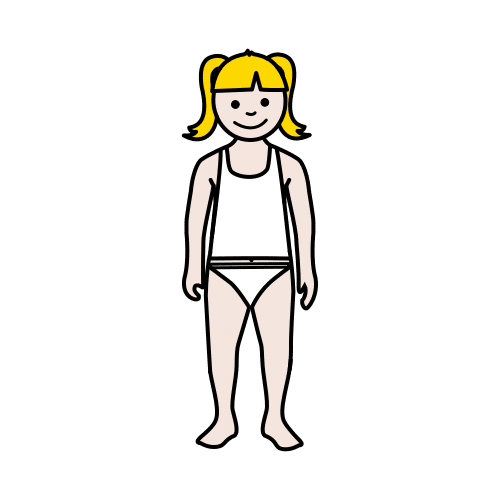
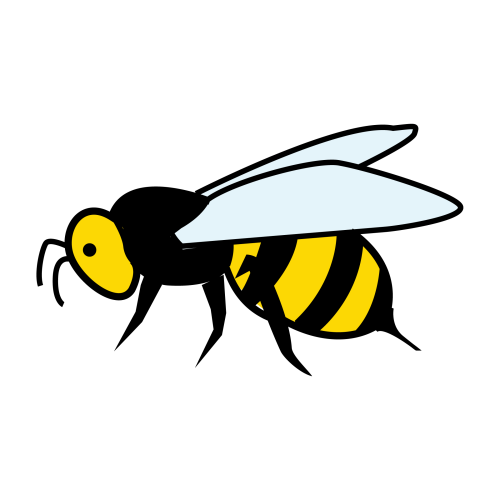
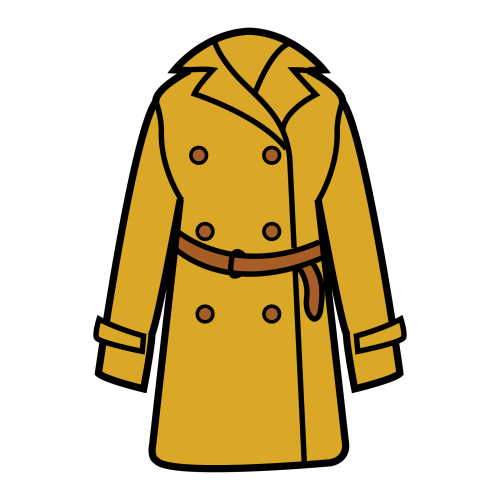
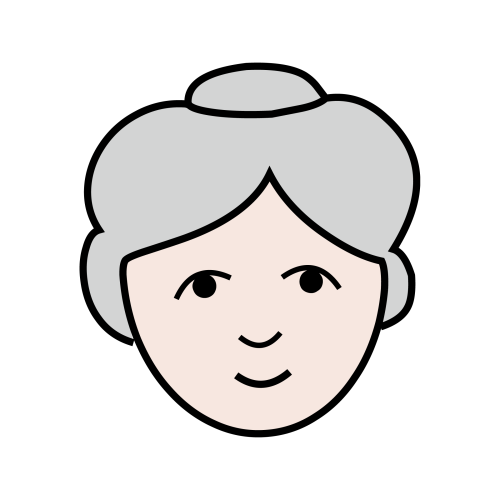
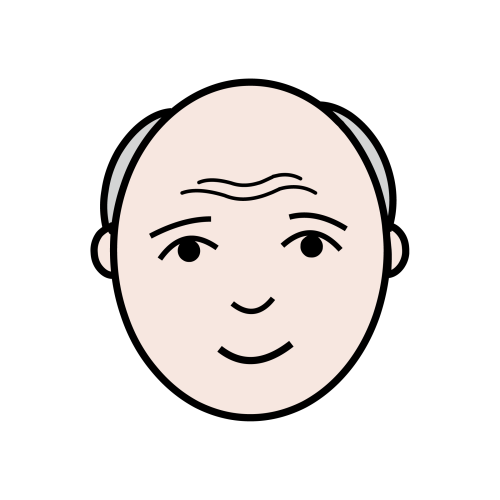
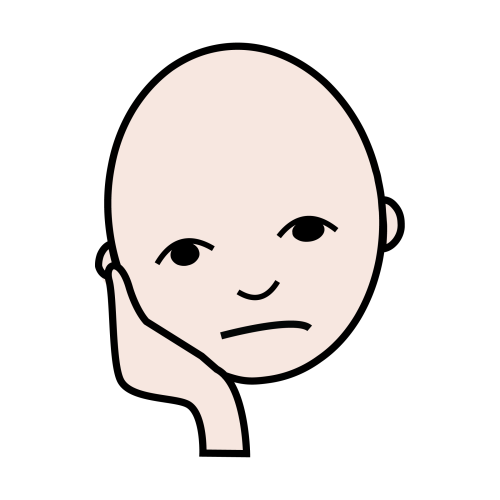
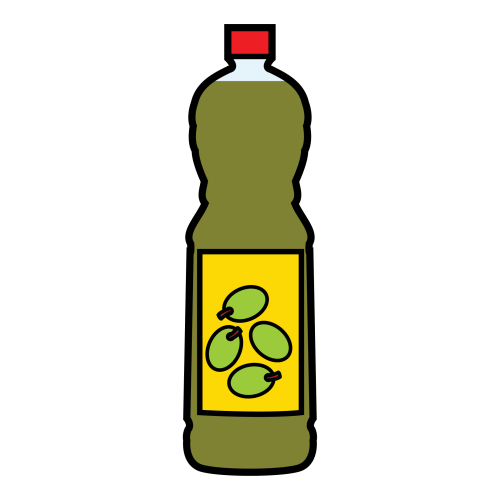
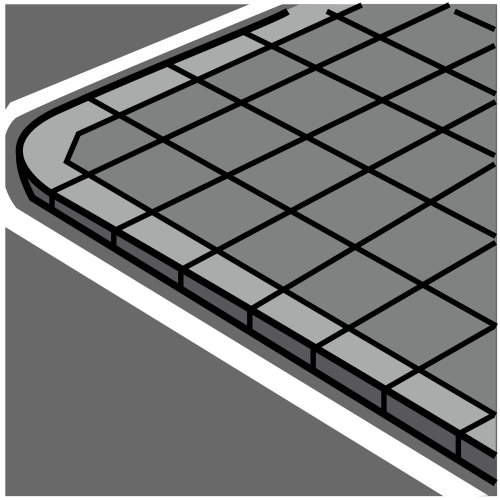
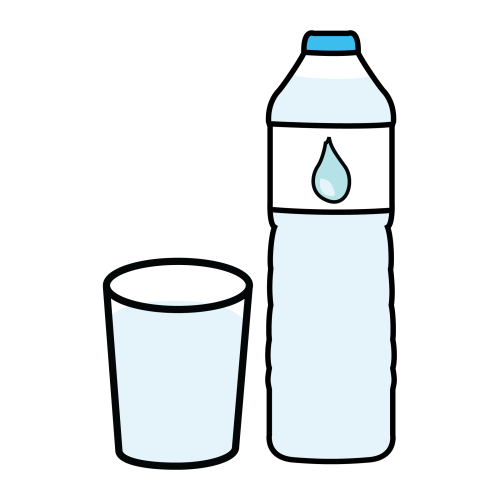
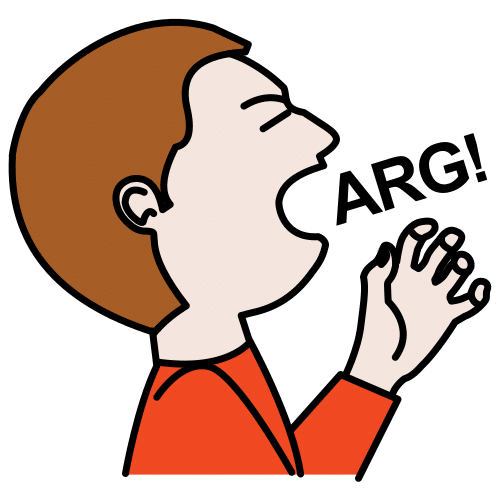
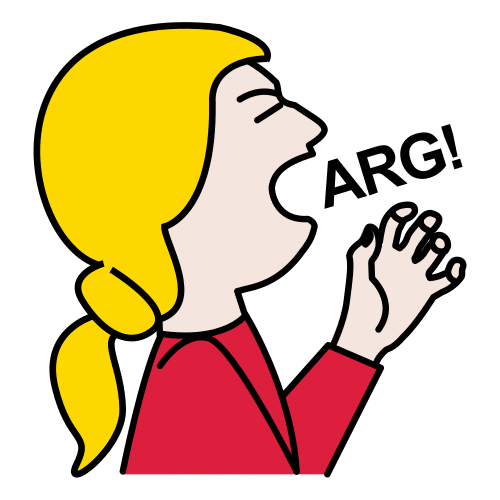
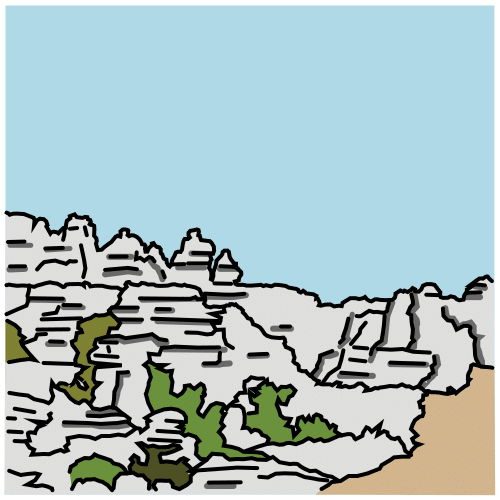
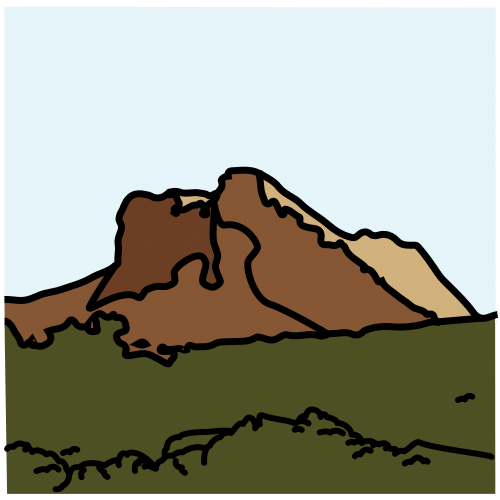
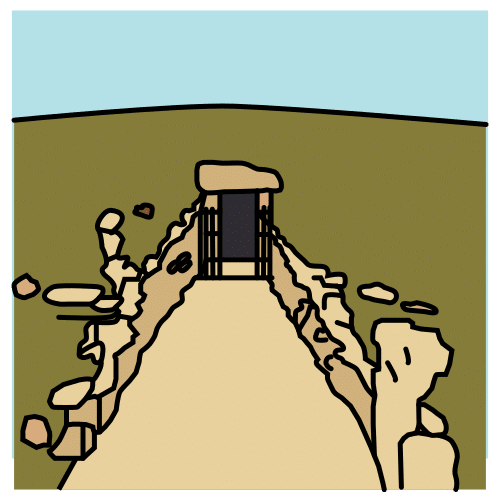
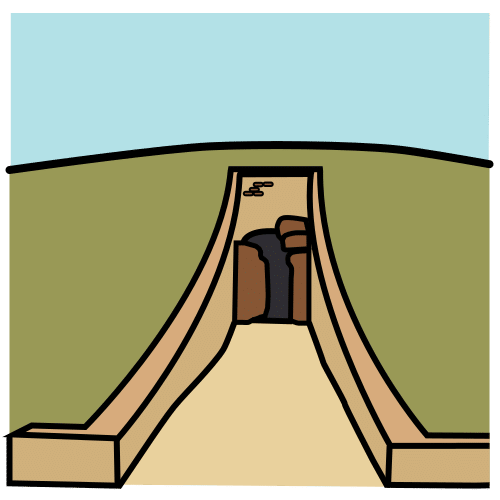
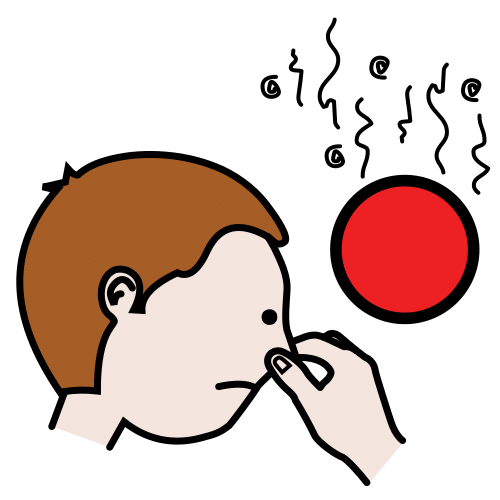
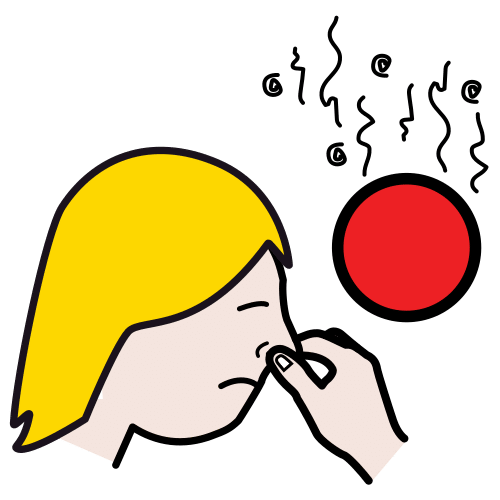
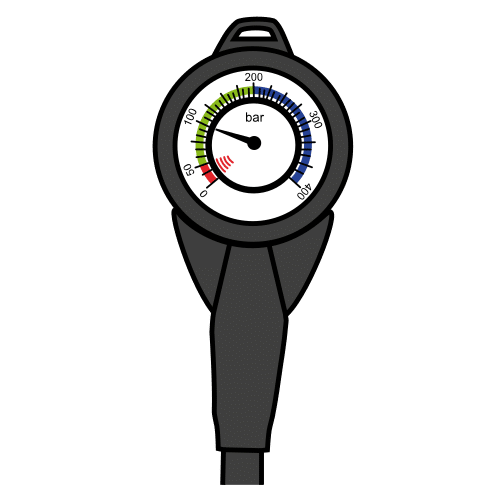
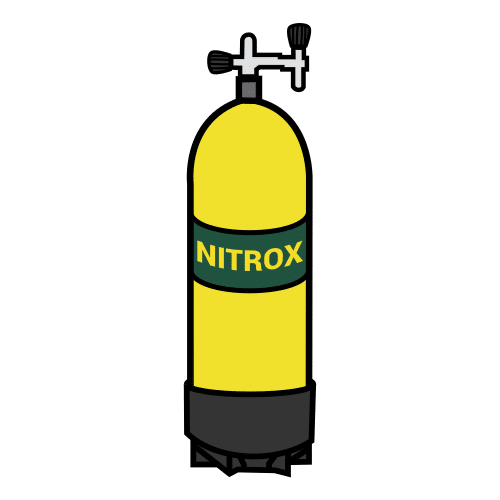
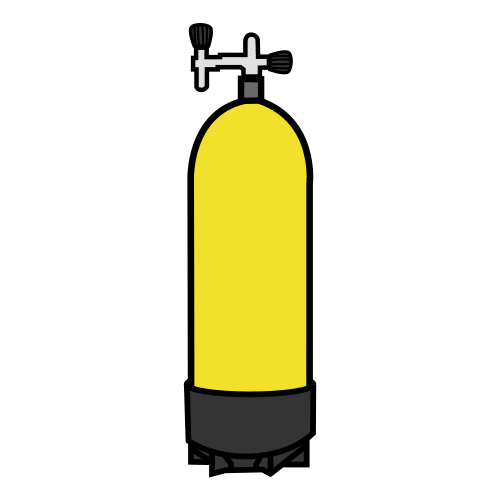

--- 20 most divergent ---


PID,Jaccard,local,HF,keywords
30960,0.000,,,local: drain the disheshf: drain
31121,0.000,,,local: float in waterhf: float
27715,0.000,,,"local: decorate the christmas tree, ornament the christmas treehf: decorate, ornament"
25119,0.000,,,"local: fry a steak, fry meathf: fry"
27049,0.000,,,"local: take off the coat, take the coat offhf: get undressed, take clothes off, take off, undress"
25405,0.000,,,"local: move away from pan, remove from panhf: move away, take out"
27717,0.000,,,"local: deposit the keys, leave the keys, put the keyshf: deposit, leave, put"
11741,0.000,,,local: take from the sinkhf: take
12315,0.000,,,local: complyhf: fulfill
21565,0.000,,,"local: hurt the hand, injure the handhf: cut, hurt, injure"

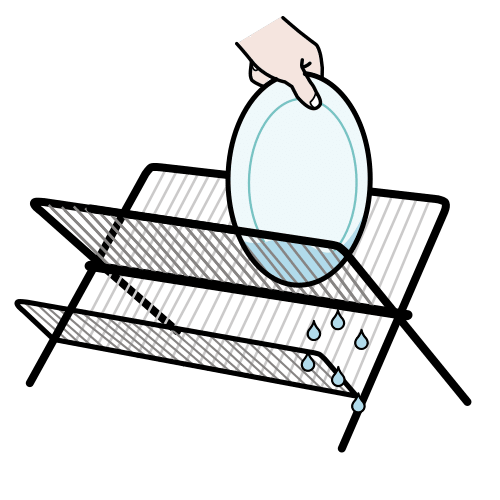
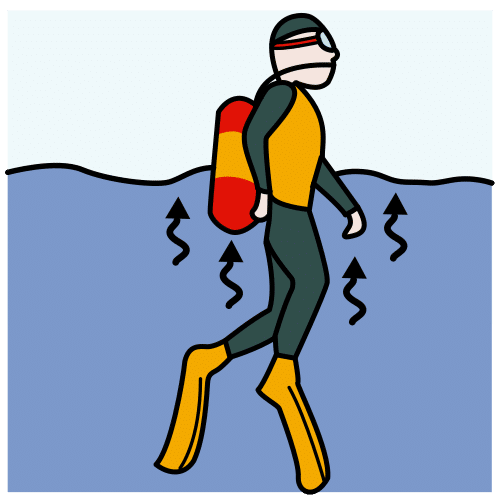
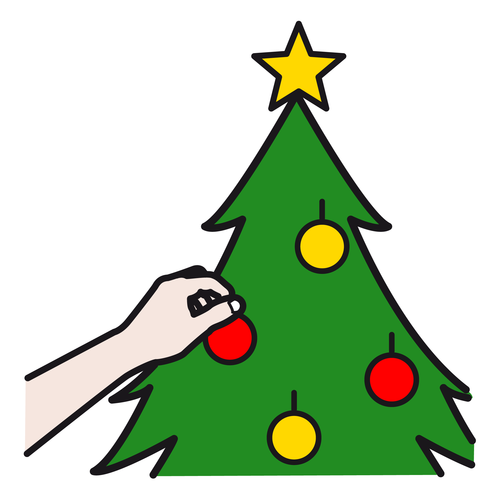
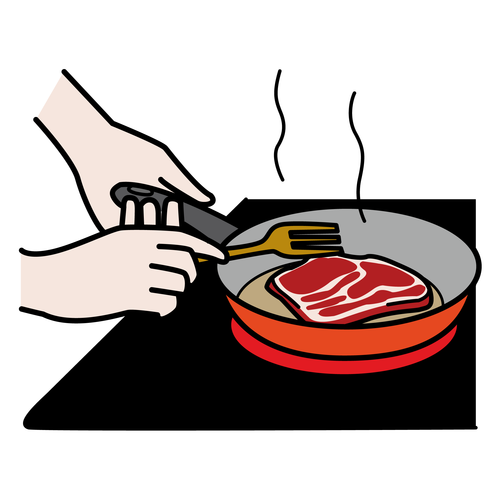
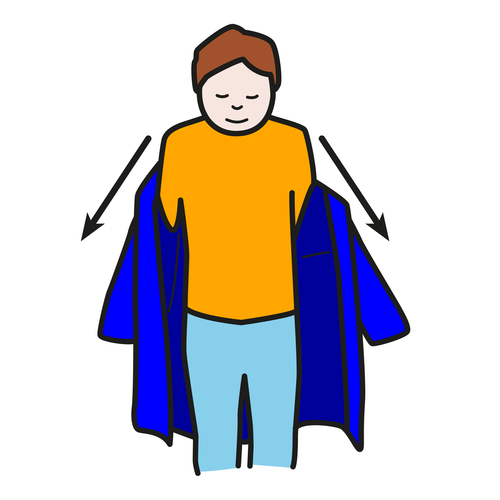
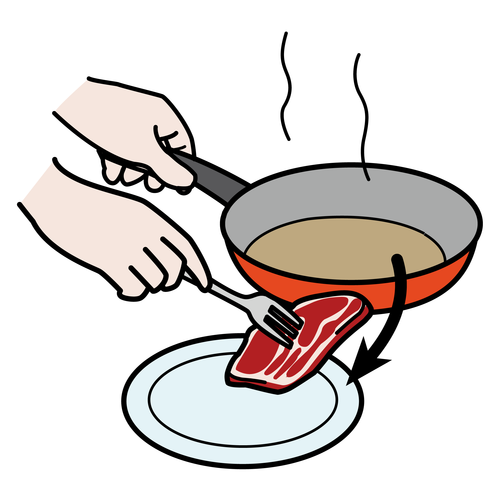
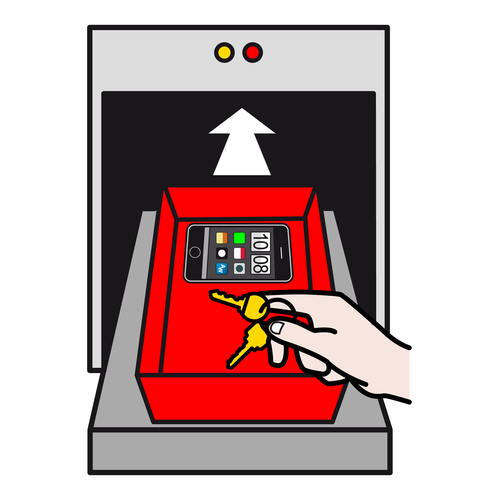
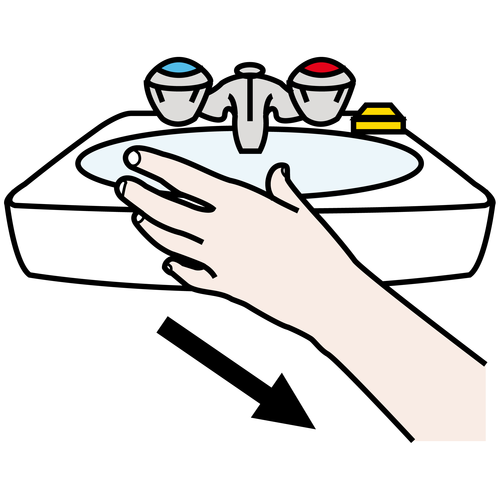
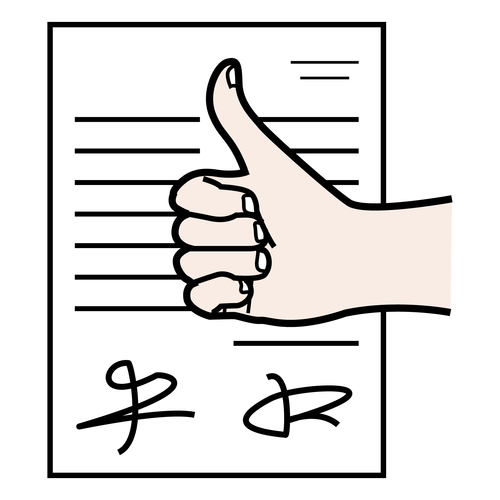
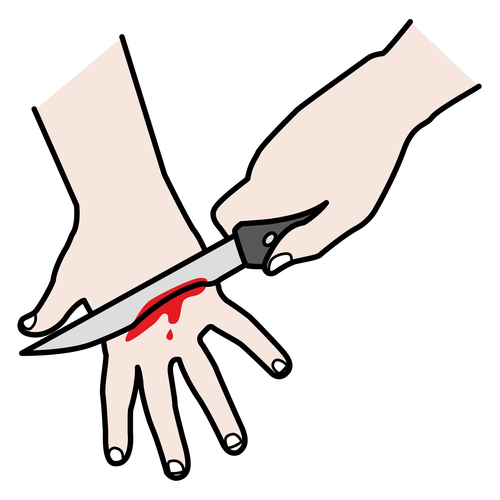
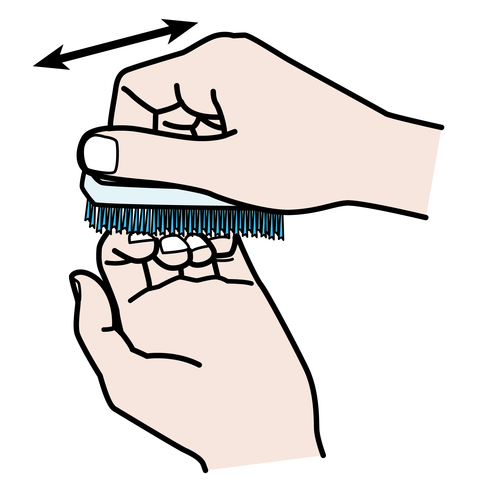
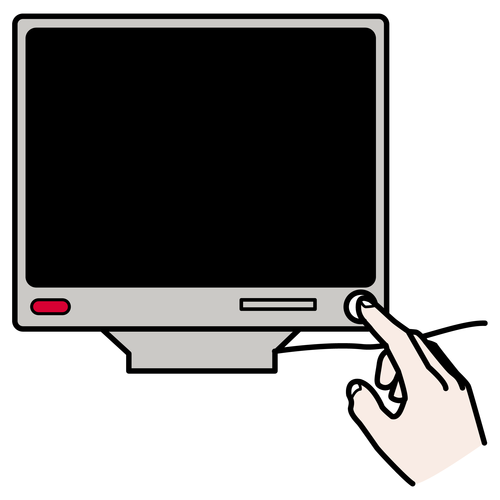
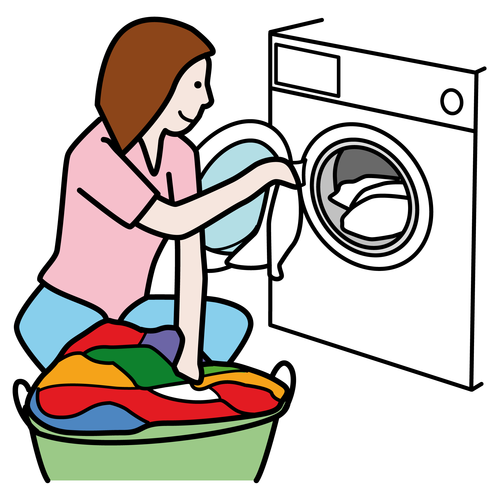
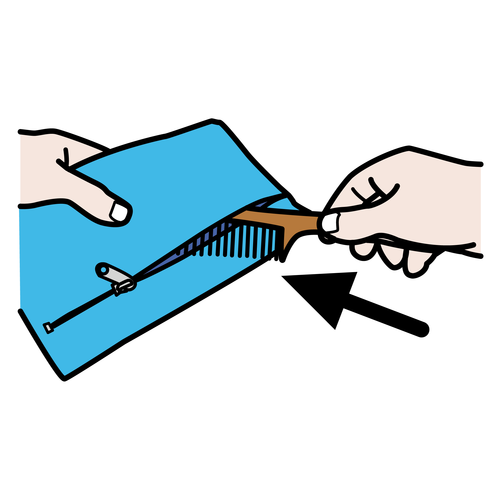
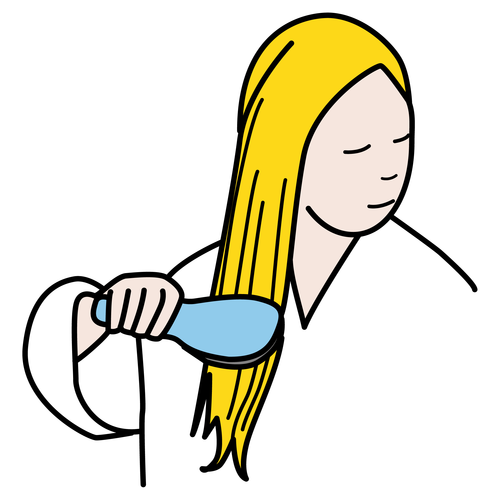
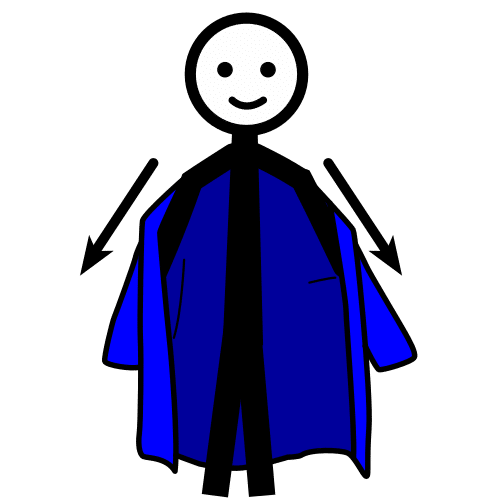
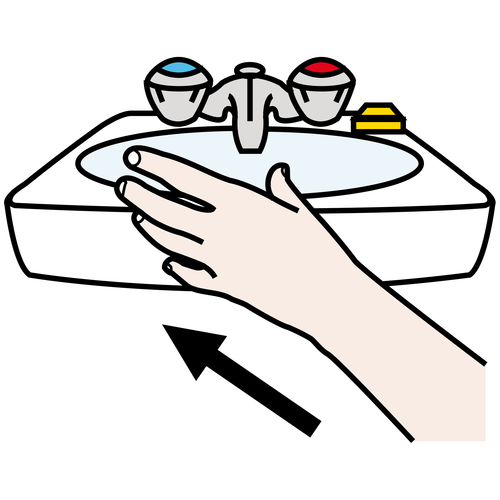
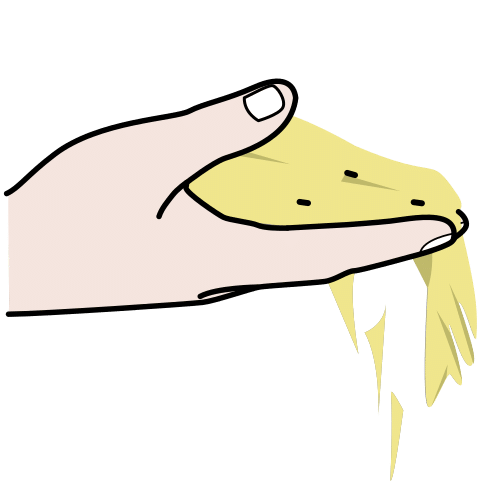
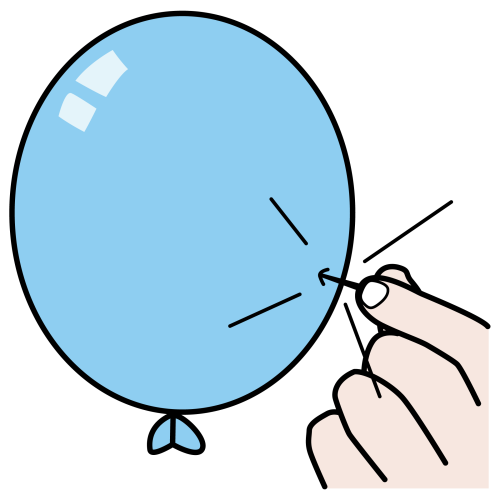
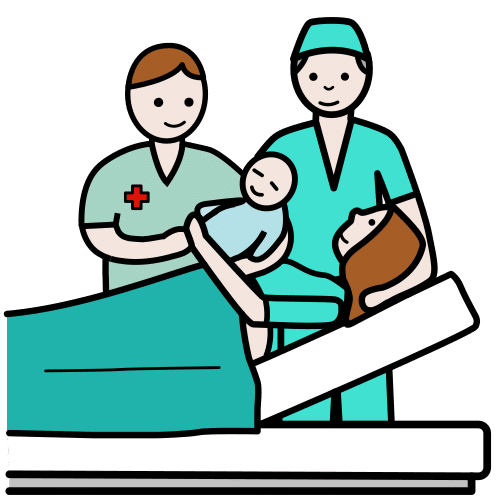

In [13]:
import base64

k = 20

ARASAAC_IMG_PATTERN = "https://static.arasaac.org/pictograms/{id}/{id}_2500.png"

loc_by_pid = df_local_clean.set_index("pictogram_id")
hf_by_pid  = df_hf_clean.set_index("pictogram_id")

def img_local(pid):
    url = ARASAAC_IMG_PATTERN.format(id=pid)
    return f"<img src='{url}' style='width:80px;height:80px;object-fit:contain'/>"

def img_hf(pid):
    if pid not in hf_by_pid.index:
        return "—"
    img_field = hf_by_pid.loc[pid, "image"]
    if img_field is None:
        return "—"
    raw = img_field["bytes"] if isinstance(img_field, dict) else img_field
    b64 = base64.b64encode(raw).decode()
    return f"<img src='data:image/png;base64,{b64}' style='width:80px;height:80px;object-fit:contain'/>"

def kw_cell(pid):
    kw_loc = get_kw_set(loc_by_pid.loc[pid, "keywords"]) if pid in loc_by_pid.index else set()
    kw_hf  = get_kw_set(hf_by_pid.loc[pid,  "keywords"]) if pid in hf_by_pid.index  else set()
    return (
        f"<span style='color:green'>local: {', '.join(sorted(kw_loc)) or '—'}</span><br>"
        f"<span style='color:darkorange'>hf: {', '.join(sorted(kw_hf)) or '—'}</span>"
    )

def make_table(df_slice):
    rows = []
    for _, r in df_slice.iterrows():
        pid = int(r["pid"])
        rows.append(f"""
        <tr>
            <td style='text-align:center'>{pid}</td>
            <td style='text-align:center'>{r['jaccard']:.3f}</td>
            <td style='text-align:center'>{img_local(pid)}</td>
            <td style='text-align:center'>{img_hf(pid)}</td>
            <td style='font-size:12px'>{kw_cell(pid)}</td>
        </tr>""")
    return f"""
    <table border='1' cellpadding='6' style='border-collapse:collapse'>
      <thead style='background:#f0f0f0'>
        <tr><th>PID</th><th>Jaccard</th><th>local</th><th>HF</th><th>keywords</th></tr>
      </thead>
      <tbody>{"".join(rows)}</tbody>
    </table>"""

print(f"--- {k} most similar ---")
display(HTML(make_table(df_jaccard.sort_values("jaccard", ascending=False).head(k))))

print(f"--- {k} most divergent ---")
display(HTML(make_table(df_jaccard.sort_values("jaccard").head(k))))

## 4. Merge sources

In [14]:
# Switch: for fields present in both datasets, choose the source.
# "local" = use local value (has synsets, type, plural — more complete)
# "hf"    = use HF value (older snapshot, different keyword granularity)

# Changing these is the lever for future ablation experiments.
FIELD_SOURCE = {
    "keywords"   : "local",   # local has type + plural; HF has only keyword + meaning
    "categories" : "local",   # same content, local preferred (more recent)
    "tags"       : "local",   # same content, local preferred
}
# synsets always from local (HF doesn't have them)
# aac/sex/violence/etc always from local (HF may not have them)

def _normalise_hf_keywords(kw_list):
    """
    Convert HF keyword schema {hasLocution, keyword, meaning}
    to local schema {type, keyword, plural, meaning}.
    type defaults to 2 (Common_Names) — safest fallback for the app.
    plural defaults to None — not available in HF.
    """
    if not kw_list:
        return []
    out = []
    for kw in kw_list:
        out.append({
            "type"    : kw.get("type", 2),       # HF sometimes has type, sometimes not
            "keyword" : kw.get("keyword", ""),
            "plural"  : kw.get("plural", None),
            "meaning" : kw.get("meaning", None),
        })
    return out

def _build_record(pid, source_df, field_source, is_hf_only=False):
    """
    Build a pictogram record dict in local JSON schema from a dataframe row.
    For overlap pictograms, field_source controls which dataset wins per field.
    For only-HF pictograms, local fields are filled with safe defaults.
    """
    loc_row = df_local_clean[df_local_clean["pictogram_id"] == pid].iloc[0] if pid in set(df_local_clean["pictogram_id"]) else None
    hf_row  = df_hf_clean[df_hf_clean["pictogram_id"] == pid].iloc[0]       if pid in set(df_hf_clean["pictogram_id"])   else None

    def from_local(field, default):
        return loc_row[field] if loc_row is not None and loc_row[field] is not None else default

    def from_hf(field, default):
        return hf_row[field]  if hf_row  is not None and hf_row[field]  is not None else default

    def pick(field, default, normalise_fn=None):
        src = field_source.get(field, "local")
        val = from_hf(field, None) if src == "hf" else from_local(field, None)
        if val is None:
            # fallback to the other source
            val = from_local(field, None) if src == "hf" else from_hf(field, None)
        if val is None:
            val = default
        return normalise_fn(val) if normalise_fn else val

    keywords = pick("keywords", [], normalise_fn=_normalise_hf_keywords if field_source.get("keywords") == "hf" else None)

    return {
        "keywords"     : keywords,
        "categories"   : pick("categories", []),
        "tags"         : pick("tags",        []),
        "synsets"      : (from_local("synsets", []) or []),   # always local
        "aac"          : bool(from_local("aac",          False) or False),
        "aac_color"    : bool(from_local("aac_color",    False) or False),
        "sex"          : bool(from_local("sex",          False) or False),
        "violence"     : bool(from_local("violence",     False) or False),
        "schematic"    : bool(from_local("schematic",    False) or False),
        "skin"         : bool(from_local("skin",         False) or False),
        "hair"         : bool(from_local("hair",         False) or False),
        "created"      : from_local("created",      None),
        "last_updated" : from_local("last_updated", None),
    }

# ── Build merged dict { id_str → record } ────────────────────────────────────
# Pre-index for speed
loc_index = df_local_clean.set_index("pictogram_id")
hf_index  = df_hf_clean.set_index("pictogram_id")

merged_json = {}

# 1. All local pictograms (overlap + only_local)
for pid, row in loc_index.iterrows():
    rec = row.to_dict()
    # apply field_source for overlap pictograms
    if pid in in_overlap and any(v == "hf" for v in FIELD_SOURCE.values()):
        hf_row = hf_index.loc[pid] if pid in hf_index.index else None
        for field, src in FIELD_SOURCE.items():
            if src == "hf" and hf_row is not None and hf_row[field] is not None:
                val = hf_row[field]
                if field == "keywords":
                    val = _normalise_hf_keywords(val)
                rec[field] = val
    # ensure booleans are real bools (pandas can return numpy.bool_)
    for bf in ("aac", "aac_color", "sex", "violence", "schematic", "skin", "hair"):
        rec[bf] = bool(rec.get(bf) or False)
    # ensure lists are real lists
    for lf in ("keywords", "categories", "tags", "synsets"):
        rec[lf] = list(rec.get(lf) or [])
    merged_json[str(pid)] = rec

    def _safe_list(val):
        if val is None:
            return []
        if isinstance(val, (list, np.ndarray)):
            return list(val)
        return []

    def _safe_bool(val, default=False):
        if val is None:
            return default
        try:
            return bool(val)
        except (ValueError, TypeError):
            return default

# 2. only-HF pictograms (24): fill missing local fields with safe defaults
for pid in only_hf:
    row = hf_index.loc[pid]
    rec = {
        "keywords"     : _normalise_hf_keywords(_safe_list(row["keywords"])),
        "categories"   : _safe_list(row["categories"]),
        "tags"         : _safe_list(row["tags"]),
        "synsets"      : [],
        "aac"          : False,
        "aac_color"    : False,
        "sex"          : False,
        "violence"     : False,
        "schematic"    : False,
        "skin"         : False,
        "hair"         : False,
        "created"      : None,
        "last_updated" : None,
    }
    merged_json[str(pid)] = rec

# ── Sanity checks ─────────────────────────────────────────────────────────────
assert len(merged_json) == len(local_ids | only_hf), "unexpected record count"
assert all(isinstance(v["keywords"], list) for v in merged_json.values()), "keywords not list"
assert all(isinstance(v["aac"], bool)      for v in merged_json.values()), "aac not bool"

gold_covered = gold_ids & {int(k) for k in merged_json}
print(f"merged records    : {len(merged_json)}")
print(f"gold covered      : {len(gold_covered)} / {len(gold_ids)}  ({len(gold_covered)/len(gold_ids)*100:.1f}%)")
print(f"gold still missing: {len(gold_ids) - len(gold_covered)}  (deprecated in ARASAAC, irrecoverable)")
print(f"\nfield sources: {FIELD_SOURCE}")

merged records    : 13804
gold covered      : 5824 / 6748  (86.3%)
gold still missing: 924  (deprecated in ARASAAC, irrecoverable)

field sources: {'keywords': 'local', 'categories': 'local', 'tags': 'local'}


In [15]:
import datetime
from collections import defaultdict

DATASETS_EN_EVAL = PROJECT_ROOT / "app" / "datasets" / "en_eval"
DATASETS_EN_EVAL.mkdir(exist_ok=True)

now = datetime.datetime.utcnow().isoformat() + "Z"

# ── 1. pictograms.json  { id_str → record } ───────────────────────────────────
with open(DATASETS_EN_EVAL / "pictograms.json", "w", encoding="utf-8") as f:
    json.dump(merged_json, f, ensure_ascii=False)
print(f"pictograms.json    : {len(merged_json)} records")

# ── 2. keyword_index.json  { keyword → [id_str, ...] } ───────────────────────
keyword_index = defaultdict(list)
for pid_str, rec in merged_json.items():
    for kw in rec.get("keywords", []):
        word = kw.get("keyword", "").strip().lower()
        if word:
            keyword_index[word].append(pid_str)
keyword_index = {k: sorted(v, key=int) for k, v in sorted(keyword_index.items())}

with open(DATASETS_EN_EVAL / "keyword_index.json", "w", encoding="utf-8") as f:
    json.dump(keyword_index, f, ensure_ascii=False)
print(f"keyword_index.json : {len(keyword_index)} entries")

# ── 3. keywords.json  [keyword, ...] ─────────────────────────────────────────
keywords_list = sorted(keyword_index.keys())

with open(DATASETS_EN_EVAL / "keywords.json", "w", encoding="utf-8") as f:
    json.dump(keywords_list, f, ensure_ascii=False)
print(f"keywords.json      : {len(keywords_list)} keywords")

# ── 4. synset_index.json  { synset_id → [id_str, ...] } ──────────────────────
synset_index = defaultdict(list)
for pid_str, rec in merged_json.items():
    for syn in rec.get("synsets", []):
        if syn:
            synset_index[syn].append(pid_str)
synset_index = {k: sorted(v, key=int) for k, v in sorted(synset_index.items())}

with open(DATASETS_EN_EVAL / "synset_index.json", "w", encoding="utf-8") as f:
    json.dump(synset_index, f, ensure_ascii=False)
print(f"synset_index.json  : {len(synset_index)} synsets")

# ── 5. _meta.json ─────────────────────────────────────────────────────────────
meta = {
    "pictograms": {
        "built_at": now,
        "count":    len(merged_json),
        "added":    len(only_hf),   # 24 only-HF pictograms added over local
        "updated":  0,
    },
    "keywords": {
        "built_at": now,
        "count":    len(keywords_list),
    },
    "keyword_index": {
        "built_at": now,
        "count":    len(keyword_index),
    },
    "synset_index": {
        "built_at": now,
        "count":    len(synset_index),
    },
}
with open(DATASETS_EN_EVAL / "_meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)
print(f"_meta.json         : ok")

print(f"\nen_eval dataset ready → {DATASETS_EN_EVAL}")

pictograms.json    : 13804 records
keyword_index.json : 15688 entries
keywords.json      : 15688 keywords
synset_index.json  : 8421 synsets
_meta.json         : ok

en_eval dataset ready → /Users/pelle/Development/GitHub/aac-mcp-agent/app/datasets/en_eval


## 5. Final evaluation dataset

In [17]:
# We remove the lines with the lost gold ids as they are impossible to correctly evaluate

EVAL_FINAL    = PROJECT_ROOT / "hf_dataset_annotation" / "eval_final.parquet"
EVAL_FILTERED = PROJECT_ROOT / "eval" / "eval_filtered.parquet"

df_eval_final = pd.read_parquet(EVAL_FINAL)
print(f"eval_final    : {len(df_eval_final):>6,} rows  ×  {df_eval_final.shape[1]} cols")

def _has_missing_gold(row) -> bool:
    ids = row["best_id"]
    ids = ids if isinstance(ids, (list, np.ndarray)) else [ids]
    return any(int(v) in missing for v in ids if v is not None)

invalid_mask     = df_eval_final.apply(_has_missing_gold, axis=1)
df_eval_filtered = df_eval_final[~invalid_mask].reset_index(drop=True)

print(f"rows removed  : {invalid_mask.sum():>6,}  (≥1 irrecoverable gold)")
print(f"eval_filtered : {len(df_eval_filtered):>6,} rows")

# Sanity: every gold ID in the filtered set must exist in merged_ids
all_gold_ok = all(
    int(v) in merged_ids
    for ids in df_eval_filtered["best_id"]
    for v in (ids if isinstance(ids, (list, np.ndarray)) else [ids])
    if v is not None
)
print(f"coverage check (all gold in merged_ids): {'✓' if all_gold_ok else '✗  PROBLEM'}")

df_eval_filtered.to_parquet(EVAL_FILTERED, index=False)
print(f"\nSaved → {EVAL_FILTERED}")
print(f"Δ rows vs eval_final: {len(df_eval_final) - len(df_eval_filtered):,} removed  "
      f"({(len(df_eval_final) - len(df_eval_filtered)) / len(df_eval_final) * 100:.1f}%)")

eval_final    : 54,792 rows  ×  8 cols
rows removed  : 20,659  (≥1 irrecoverable gold)
eval_filtered : 34,133 rows
coverage check (all gold in merged_ids): ✓

Saved → /Users/pelle/Development/GitHub/aac-mcp-agent/eval/eval_filtered.parquet
Δ rows vs eval_final: 20,659 removed  (37.7%)
